In [484]:
## Introduction

# This notebook demonstrates Decision Tree classification using the Iris dataset.
# The goal is to classify flower species based on their features.
# We build, train, and evaluate a Decision Tree model using Scikit-learn.
# Finally, we visualize the tree and analyze model performance.

In [485]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [486]:
# Decision Tree Implementation using Iris Dataset

# Loading the dataset
df = pd.read_csv("IRIS.csv")

In [487]:
# Display first few records for dataset preview
df.head(5)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [488]:
# Display last few records
df.tail(5)

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


In [489]:
# Basic information about IRIS dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [490]:
# Statistical summary of data
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [491]:
# Checking unique of "species' for target column
df['species'].value_counts()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [492]:
# Separating features and target
X = df.drop('species', axis=1)
y = df['species']

In [493]:
# Spliting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [494]:
# Creating Decision Tree Model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [495]:
# Making predictions
y_pred = model.predict(X_test)

In [496]:
# DECISION TREE MODEL EVALUATION

In [497]:
# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [498]:
# Classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [499]:
# Confusion matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


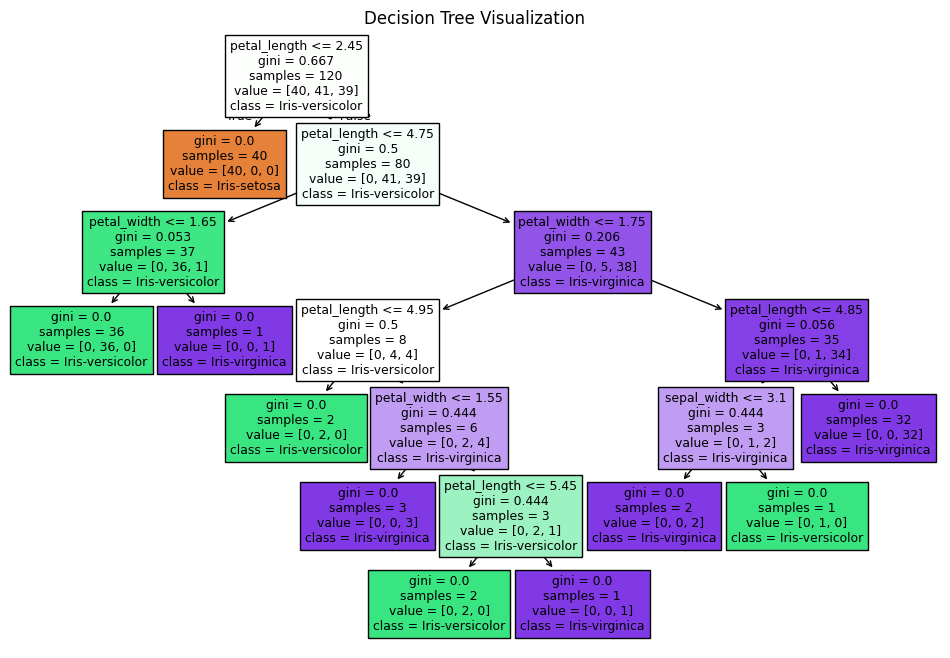

In [500]:
# Ploting decision tree
plt.figure(figsize=(12, 8))
plot_tree(model, feature_names=X.columns, class_names=model.classes_, filled=True)
plt.title("Decision Tree Visualization")
plt.show()

In [501]:
# Feature importance
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False)

petal_length    0.906143
petal_width     0.077186
sepal_width     0.016670
sepal_length    0.000000
dtype: float64

In [502]:
# CONTROLLED DECISION TREE

In [503]:
# Train with limited depth
model_limited = DecisionTreeClassifier(max_depth=3, random_state=42)
model_limited.fit(X_train, y_train)

# Predictions
y_pred_limited = model_limited.predict(X_test)

# Accuracy
print("Accuracy with max_depth=3:", accuracy_score(y_test, y_pred_limited))

Accuracy with max_depth=3: 1.0


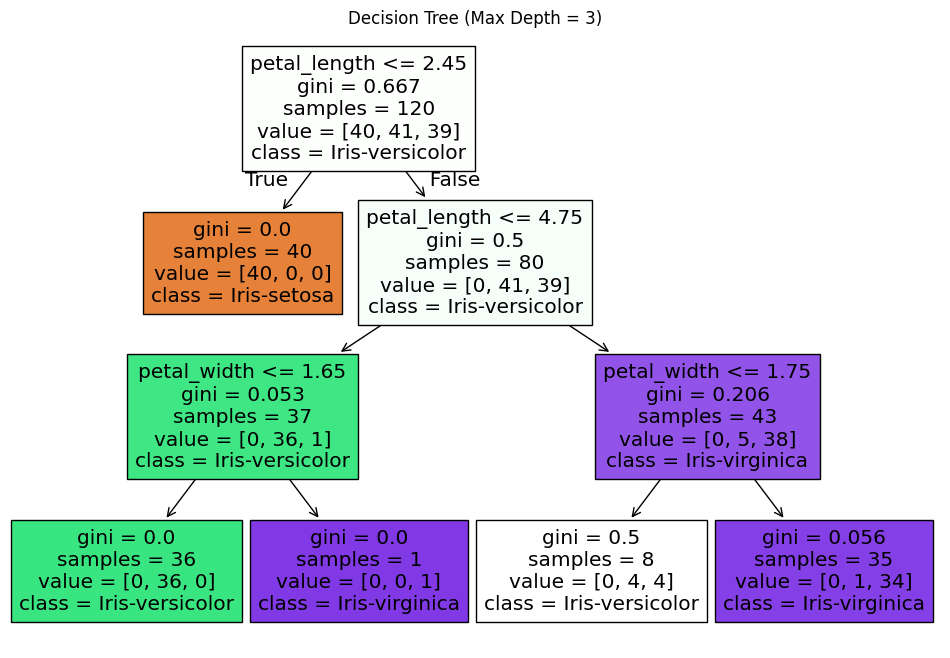

In [504]:
# Plot limited tree
plt.figure(figsize=(12, 8))
plot_tree(model_limited, feature_names=X.columns, class_names=model.classes_, filled=True)
plt.title("Decision Tree (Max Depth = 3)")
plt.show()

In [505]:
# Decision Path Analysis

# Analyze how a single sample flows through the tree
sample = X_test.iloc[0:1]

node_indicator = model.decision_path(sample)
leaf_id = model.apply(sample)

print("Decision Path Nodes:", node_indicator.indices)
print("Leaf Node:", leaf_id)

Decision Path Nodes: [0 2 3 4]
Leaf Node: [4]


In [506]:
# Get Tree Depth and Leaves info
print("Tree Depth:", model.get_depth())
print("Number of Leaves:", model.get_n_leaves())

Tree Depth: 6
Number of Leaves: 10


C:\Users\Sanket M\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


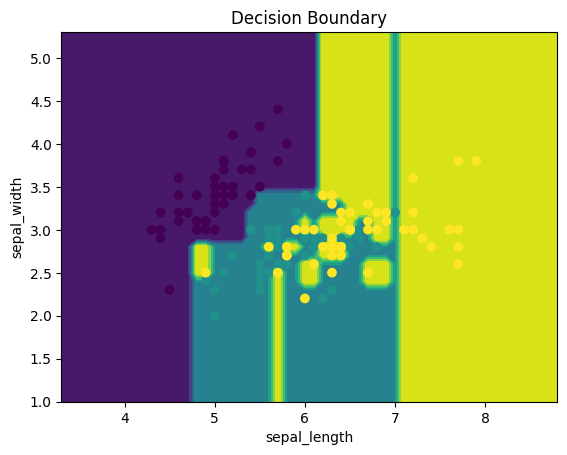

In [507]:
# Decision boundary using first two features

import numpy as np

# Use only first 2 features
X_vis = X.iloc[:, :2]

# Convert target to numeric
y_vis_encoded, uniques = pd.factorize(y)

# Train model
model_vis = DecisionTreeClassifier()
model_vis.fit(X_vis, y_vis_encoded)

# Create mesh grid
x_min, x_max = X_vis.iloc[:, 0].min() - 1, X_vis.iloc[:, 0].max() + 1
y_min, y_max = X_vis.iloc[:, 1].min() - 1, X_vis.iloc[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.1),
    np.arange(y_min, y_max, 0.1)
)

# Predict on grid
Z = model_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure()
plt.contourf(xx, yy, Z)
plt.scatter(X_vis.iloc[:, 0], X_vis.iloc[:, 1], c=y_vis_encoded)
plt.title("Decision Boundary")
plt.xlabel(X_vis.columns[0])
plt.ylabel(X_vis.columns[1])
plt.show()

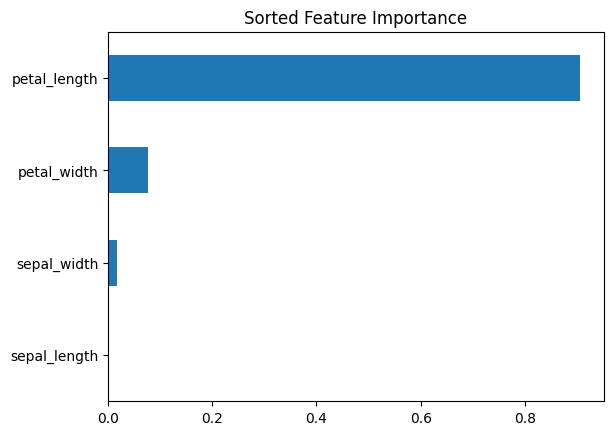

In [508]:
# Plot sorted feature importance
importance = pd.Series(model.feature_importances_, index=X.columns)

plt.figure()
importance.sort_values(ascending=True).plot(kind='barh')
plt.title("Sorted Feature Importance")
plt.show()

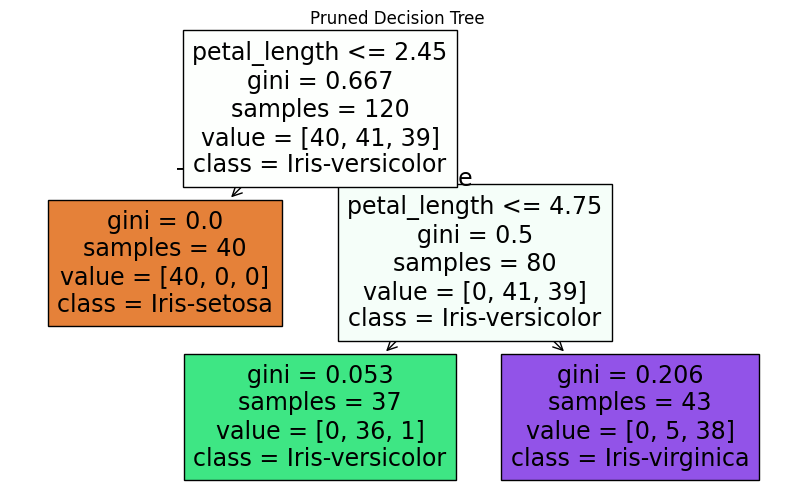

In [509]:
# Pruned tree using max_depth
pruned_model = DecisionTreeClassifier(max_depth=2, random_state=42)
pruned_model.fit(X_train, y_train)

plt.figure(figsize=(10,6))
plot_tree(pruned_model, feature_names=X.columns, class_names=model.classes_, filled=True)
plt.title("Pruned Decision Tree")
plt.show()

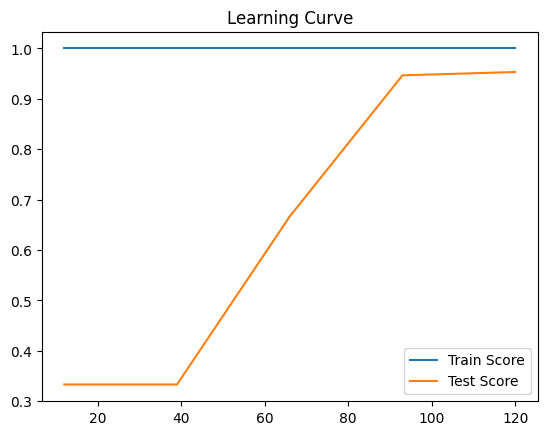

In [510]:
# Learning curve analysis
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    model, X, y, cv=5
)

plt.figure()
plt.plot(train_sizes, train_scores.mean(axis=1), label="Train Score")
plt.plot(train_sizes, test_scores.mean(axis=1), label="Test Score")
plt.legend()
plt.title("Learning Curve")
plt.show()

In [511]:
# Compare accuracy for different depths
for depth in range(1, 6):
    temp_model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    temp_model.fit(X_train, y_train)
    pred = temp_model.predict(X_test)
    print(f"Depth {depth} -> Accuracy:", accuracy_score(y_test, pred))

Depth 1 -> Accuracy: 0.6333333333333333
Depth 2 -> Accuracy: 0.9666666666666667
Depth 3 -> Accuracy: 1.0
Depth 4 -> Accuracy: 1.0
Depth 5 -> Accuracy: 1.0


In [512]:
# Save model
import joblib
joblib.dump(model, "decision_tree_model.pkl")

['decision_tree_model.pkl']

In [513]:
# Load model
loaded_model = joblib.load("decision_tree_model.pkl")

In [514]:
# Testing five predictions

# Sample 1
sample1 = X_test.iloc[1:2]
print("Prediction 1:", loaded_model.predict(sample1))

Prediction 1: ['Iris-setosa']


In [515]:
# Sample 2
sample2 = X_test.iloc[2:3]
print("Prediction 2:", loaded_model.predict(sample2))

Prediction 2: ['Iris-virginica']


In [516]:
# Sample 3
sample3 = X_test.iloc[3:4]
print("Prediction 3:", loaded_model.predict(sample3))

Prediction 3: ['Iris-versicolor']


In [517]:
# Sample 4
sample4 = X_test.iloc[5:6]
print("Prediction 4:", loaded_model.predict(sample4))

Prediction 4: ['Iris-setosa']


In [518]:
# Sample 5
sample5 = X_test.iloc[4:5]
print("Prediction 5:", loaded_model.predict(sample5))

Prediction 5: ['Iris-versicolor']


In [519]:
# CONCLUSION

# The Decision Tree model successfully classified the Iris dataset with high accuracy.
# Visualization helped in understanding how features influence predictions.
# Model tuning improved performance and reduced overfitting.
# Overall, this implementation provides a simple yet powerful approach to classification problems.